# 01 · Image segmentation basics

**Segmenting an image** means giving a label to every pixel: "animal", "background", "road"…

In this notebook we explore 3 methods, from the simplest to the most powerful:
1. **Thresholding**: separate bright pixels from dark pixels
2. **Edges** (Canny): find the boundaries between objects
3. **K-means**: group pixels by color

And to finish, a preview of what a **neural network** does (YOLO).

**Prerequisites:** basic Python and NumPy.

## 0. Setup

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def show(images, titles):
    # Display several images side by side
    fig, axes = plt.subplots(1, len(images), figsize=(5 * len(images), 5))
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap="gray")
        ax.set_title(title)
        ax.axis("off")
    plt.show()

## 1. Load an image

OpenCV reads images as **BGR** (Blue, Green, Red), while matplotlib expects **RGB**. So we convert.

Color: (375, 500, 3)   Gray: (375, 500)


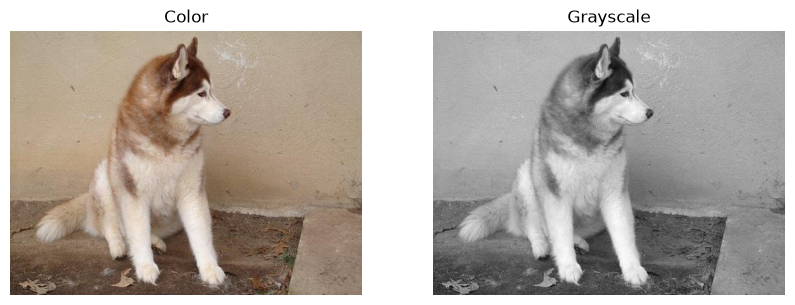

In [2]:
img_bgr = cv2.imread("../../img/dog.png")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print("Color:", img_rgb.shape, "  Gray:", gray.shape)
show([img_rgb, gray], ["Color", "Grayscale"])

## 2. Thresholding

The simplest idea: pick a **threshold** (here 127).
- pixel > 127 → white (255)
- pixel ≤ 127 → black (0)

We get a **binary** image: only 2 classes.

In [ ]:
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Otsu picks the threshold automatically from the histogram
otsu_threshold, binary_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

show([binary, binary_otsu], ["Threshold = 127", f"Otsu (threshold = {otsu_threshold:.0f})"])

**Limitation:** thresholding only looks at brightness. A dark animal on a dark background won't be separated.

## 3. Edges (Canny)

Instead of classifying pixels, we look for **boundaries**: places where brightness changes sharply.

We first apply a **blur** to remove noise, otherwise every tiny detail becomes an edge.

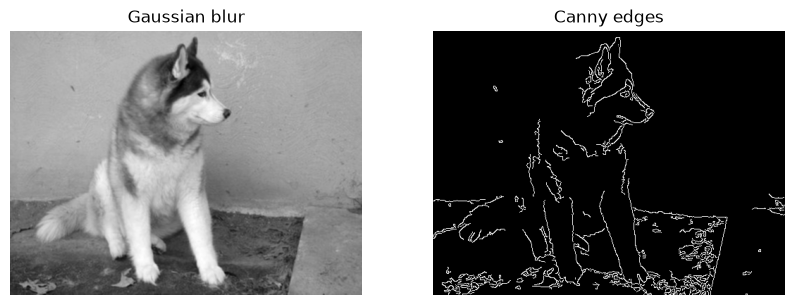

In [3]:
blur = cv2.GaussianBlur(gray, (3, 3), 0)
edges = cv2.Canny(blur, 50, 150)   # 50 and 150: low and high thresholds

show([blur, edges], ["Gaussian blur", "Canny edges"])

**Limitation:** we get lines, not regions. The contour is not always closed.

## 4. K-means: grouping pixels by color

Each pixel is a point `(B, G, R)` in color space.
K-means sorts them into **K groups** of similar colors, then replaces each pixel with the average color of its group.

In [4]:
image = cv2.imread("../../img/dog_cat.png")

# One row per pixel, 3 columns (B, G, R)
pixels = np.float32(image.reshape(-1, 3))

K = 5
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
_, labels, centers = cv2.kmeans(pixels, K, None, criteria, 10, cv2.KMEANS_PP_CENTERS)

print("labels:", labels.shape, "-> the group number of each pixel")
print("centers:", centers.shape, "-> the average color of each group")

labels: (39960, 1) -> the group number of each pixel
centers: (5, 3) -> the average color of each group


### The trick to rebuild the image

`centers[labels]` replaces each group number with the matching color. Small example:

In [5]:
colors = np.array([10, 20, 30])
groups = np.array([0, 0, 2, 1])
colors[groups]   # -> [10, 10, 30, 20]

array([10, 10, 30, 20])

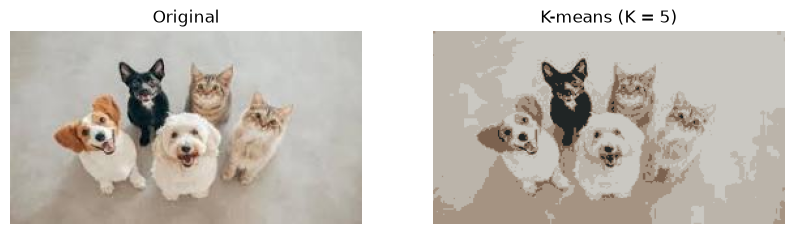

In [6]:
segmented = np.uint8(centers)[labels.flatten()].reshape(image.shape)

show([cv2.cvtColor(image, cv2.COLOR_BGR2RGB), cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB)],
     ["Original", f"K-means (K = {K})"])

**Limitation:** K-means doesn't know what a "dog" is. It only groups similar colors.

## 5. Preview: a neural network (YOLO)

A network trained on thousands of images **recognizes objects** and gives one mask per object.
How does it work inside? That's what the next notebooks are about.

Objects found: ['dog', 'cat', 'dog', 'dog', 'cat']


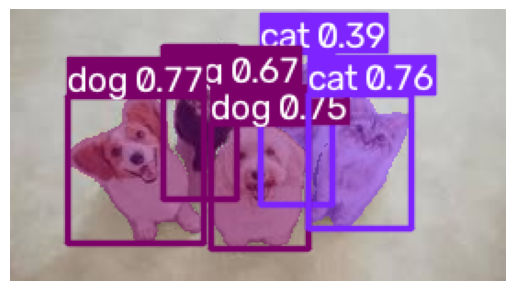

In [7]:
from ultralytics import YOLO

model = YOLO("../../models/yolo26n-seg.pt")
result = model.predict("../../img/dog_cat.png", verbose=False)[0]

print("Objects found:", [result.names[int(c)] for c in result.boxes.cls])
plt.imshow(result.plot()[:, :, ::-1])   # plot() returns BGR
plt.axis("off")
plt.show()

## Summary

| Method | Looks at | Limitation |
|---|---|---|
| Thresholding | brightness | only 2 classes |
| Canny | sharp changes | lines, not regions |
| K-means | color | doesn't understand objects |
| YOLO | learned patterns | needs training |



**Next:** [02 · Feature maps](02_feature_maps.ipynb)